# Data Pre-processing

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [40]:
dataset = pd.read_csv("Data.csv")
X_raw = dataset.iloc[:, :-1].values
y_raw = dataset.iloc[:, -1].values
dfX_raw = dataset.iloc[:, :-1]
seriesy_rawdfX = dataset.iloc[:, -1]

In [41]:
# get the raw data

dfX = dfX_raw.copy()
seriesy = seriesy_rawdfX.copy()
X = X_raw.copy()
y = y_raw.copy()

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# ct = ColumnTransformer(transformers=[("encode", "drop", [0])], remainder="passthrough")
ct = ColumnTransformer(transformers=[("encode", OneHotEncoder(), [0])], remainder="passthrough")
# ct = ColumnTransformer(transformers=[("encode", OneHotEncoder(), [0])])
X = np.array(ct.fit_transform(X))

In [43]:
print(X)

[[1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [0.0 1.0 0.0 30.0 54000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 1.0 0.0 40.0 nan]
 [1.0 0.0 0.0 35.0 58000.0]
 [0.0 0.0 1.0 nan 52000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


## Encoding the Dependent Variable

In [44]:
from sklearn.preprocessing import LabelEncoder  # used to convert the categorical target labels into numerical labels
le = LabelEncoder()
y = le.fit_transform(y)

In [45]:
print(y)

[0 1 0 0 1 1 0 1 0 1]


In [46]:
le.fit(["india", "paris", "paris", "tokyo", "amsterdam"])
print(le.transform(["india", "amsterdam", "tokyo", "paris"]))

[1 0 3 2]


## Spliting the dataset into Training set and Test set

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)    # random-state is used for reproducibility

In [48]:
print(X_train)

[[0.0 0.0 1.0 nan 52000.0]
 [0.0 1.0 0.0 40.0 nan]
 [1.0 0.0 0.0 44.0 72000.0]
 [0.0 0.0 1.0 38.0 61000.0]
 [0.0 0.0 1.0 27.0 48000.0]
 [1.0 0.0 0.0 48.0 79000.0]
 [0.0 1.0 0.0 50.0 83000.0]
 [1.0 0.0 0.0 35.0 58000.0]]


In [49]:
print(X_test)

[[0.0 1.0 0.0 30.0 54000.0]
 [1.0 0.0 0.0 37.0 67000.0]]


In [50]:
print(y_train)

[0 1 0 0 1 1 0 1]


In [51]:
print(y_test)

[0 1]


## Features Scaling

In [52]:
from sklearn.preprocessing import StandardScaler    # Z_score = [(x - x_bar) / s] or [(x - mu) / sigma]
sc = StandardScaler()                               # x -> data
X_train[:, 3:] = sc.fit_transform(X_train[:, 3:])   # x_bar / mu -> sample / population mean
X_test[:, 3:] = sc.transform(X_test[:, 3:])         # s / sigma -> sample / population  standard deviation

In [53]:
print(X_train)

[[0.0 0.0 1.0 nan -1.0182239953527132]
 [0.0 1.0 0.0 -0.038910211282047996 nan]
 [1.0 0.0 0.0 0.5058327466666259 0.583476671494251]
 [0.0 0.0 1.0 -0.3112816902563849 -0.2974586952715793]
 [0.0 0.0 1.0 -1.809324824615238 -1.3385641287221062]
 [1.0 0.0 0.0 1.0505757046152997 1.1440719048906884]
 [0.0 1.0 0.0 1.3229471835896367 1.4644120382600814]
 [1.0 0.0 0.0 -0.7198389087178904 -0.537713795298624]]


In [54]:
print(X_test)

[[0.0 1.0 0.0 -1.4007676061537326 -0.8580539286680168]
 [1.0 0.0 0.0 -0.4474674297435534 0.18305150478250995]]


# MatPlotLib Basics

## Our first Visualization

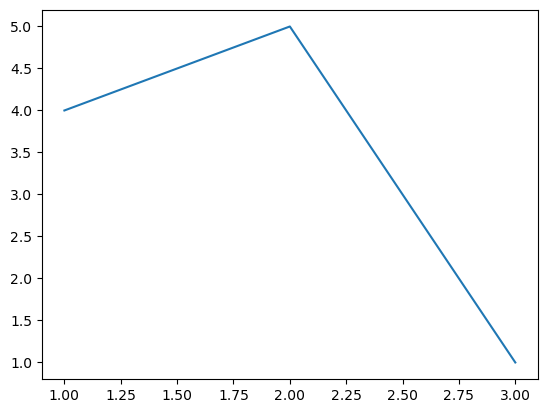

In [55]:
# Importing pyplot
# matplotlib is a visualization library, pyplot is a module that containts function for creating graphs

# from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

# Plotting to our canvas
plt.plot([1, 2, 3], [4, 5, 1])

# Showing what we plotted
plt.show()

## Adding Titles and Labels

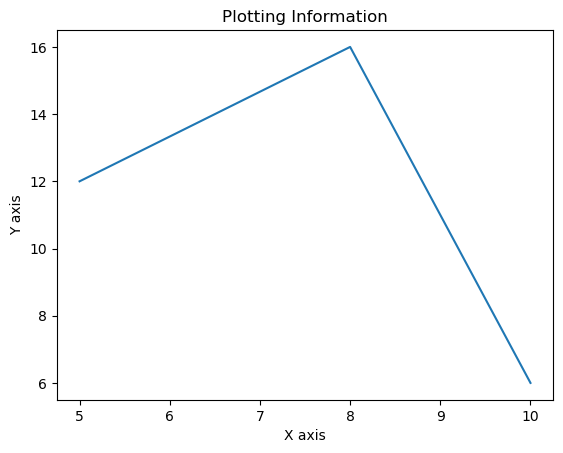

In [56]:
import matplotlib.pyplot as plt

x = [5, 8, 10]
y = [12, 16, 6]
plt.plot(x, y)
plt.title("Plotting Information")

# Putting labelto both the axis
plt.ylabel("Y axis")
plt.xlabel("X axis")

plt.show()

## Adding Styling

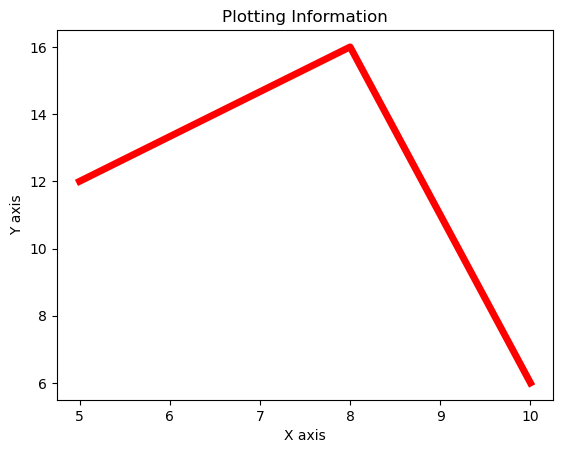

In [57]:
import matplotlib.pyplot as plt
import matplotlib.style

x = [5, 8, 10]
y = [12, 16, 6]
plt.plot(x, y, color="red", linewidth=5)
plt.title("Plotting Information")

# Putting labelto both the axis
plt.ylabel("Y axis")
plt.xlabel("X axis")

plt.show()

## Saving it to File

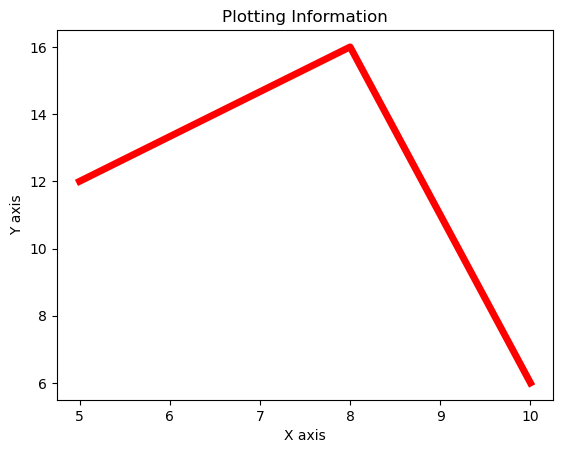

In [58]:
import matplotlib.pyplot as plt
import matplotlib.style

x = [5, 8, 10]
y = [12, 16, 6]
plt.plot(x, y, color="red", linewidth=5)
plt.title("Plotting Information")

# Putting labelto both the axis
plt.ylabel("Y axis")
plt.xlabel("X axis")

plt.savefig("MyPlot.png", format="png")

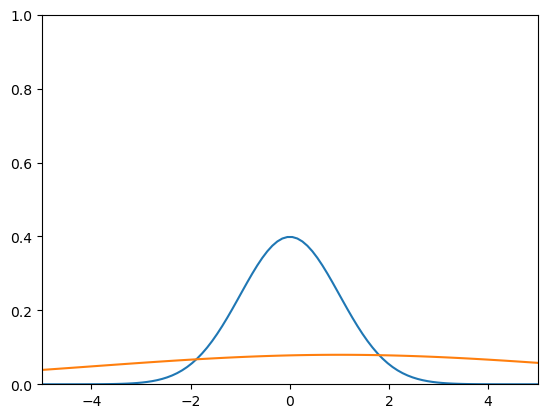

In [63]:
from scipy.stats import norm

axes = plt.axes()
axes.set_xlim([-5, 5])
axes.set_ylim([0, 1.0])
# axes.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])
# axes.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

x = np.linspace(-5, 5, 100)
plt.plot(x, norm.pdf(x))
plt.plot(x, norm.pdf(x, 1.0, 5.0))  # mean = 1.0 and standard deviation = 0.5
plt.show()